<a href="https://colab.research.google.com/github/fabianoseller/PucPosEstat/blob/main/AN%C3%81LISE_MULTIVARIADA_VINICIUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/datasets/uom190346a/disease-symptoms-and-patient-profile-dataset

--- 1. Análise Discriminante Linear (LDA) ---


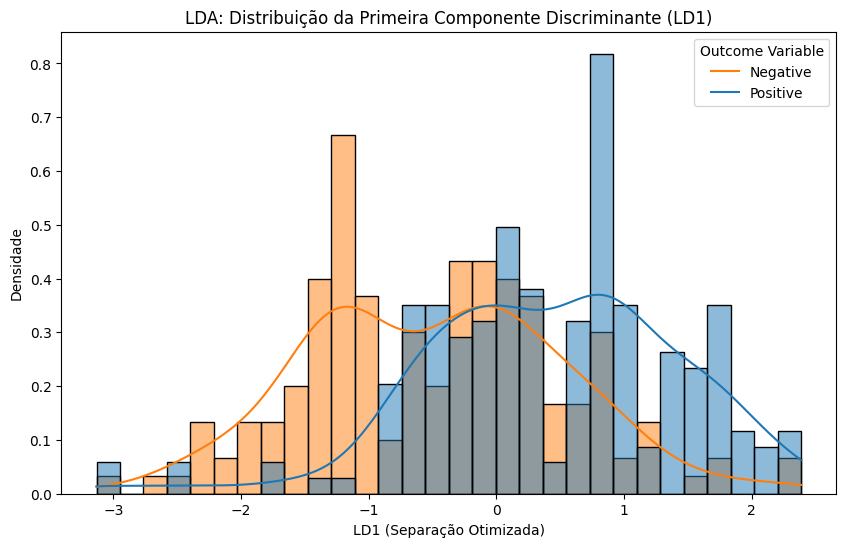


Coeficientes da LD1 (Pesos que Discriminam Positivo vs Negativo):
Cholesterol Level_Encoded    0.698684
Fever                        0.395141
Fatigue                      0.288003
Difficulty Breathing         0.219350
Blood Pressure_Encoded       0.089883
Age                          0.057220
Cough                       -0.030012
Gender                      -0.356253
dtype: float64

--- 2. Análise de Componentes Principais (PCA) ---


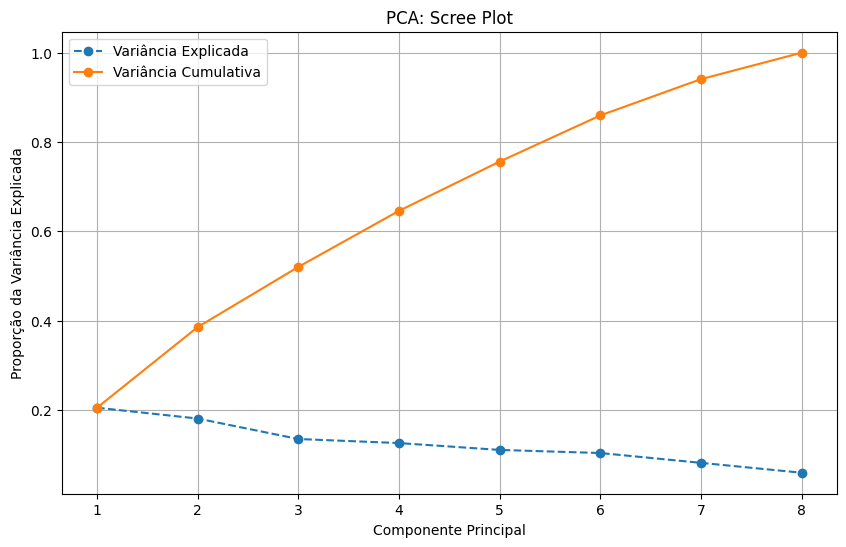


Variância Explicada por Componente:
  Componente  Variância Explicada  Variância Cumulativa
0        PC1             0.204811              0.204811
1        PC2             0.180592              0.385404
2        PC3             0.134743              0.520146
3        PC4             0.125647              0.645794
4        PC5             0.110293              0.756087
5        PC6             0.103352              0.859439
6        PC7             0.081344              0.940783
7        PC8             0.059217              1.000000

--- 3. Teste Hotelling T² e Testes t Univariados ---

Hotelling T² para 8 variáveis:
Estatística T²: 72.2514
Estatística F equivalente: 8.8492
P-valor: 0.0000000001
Conclusão: H0 de vetores de médias iguais é REJEITADA.

Teste t Univariado (Importância Individual):
                     Feature       P-valor Significante (p < 0.05)
7  Cholesterol Level_Encoded  7.208804e-09                     Sim
6     Blood Pressure_Encoded  1.627364e-04                

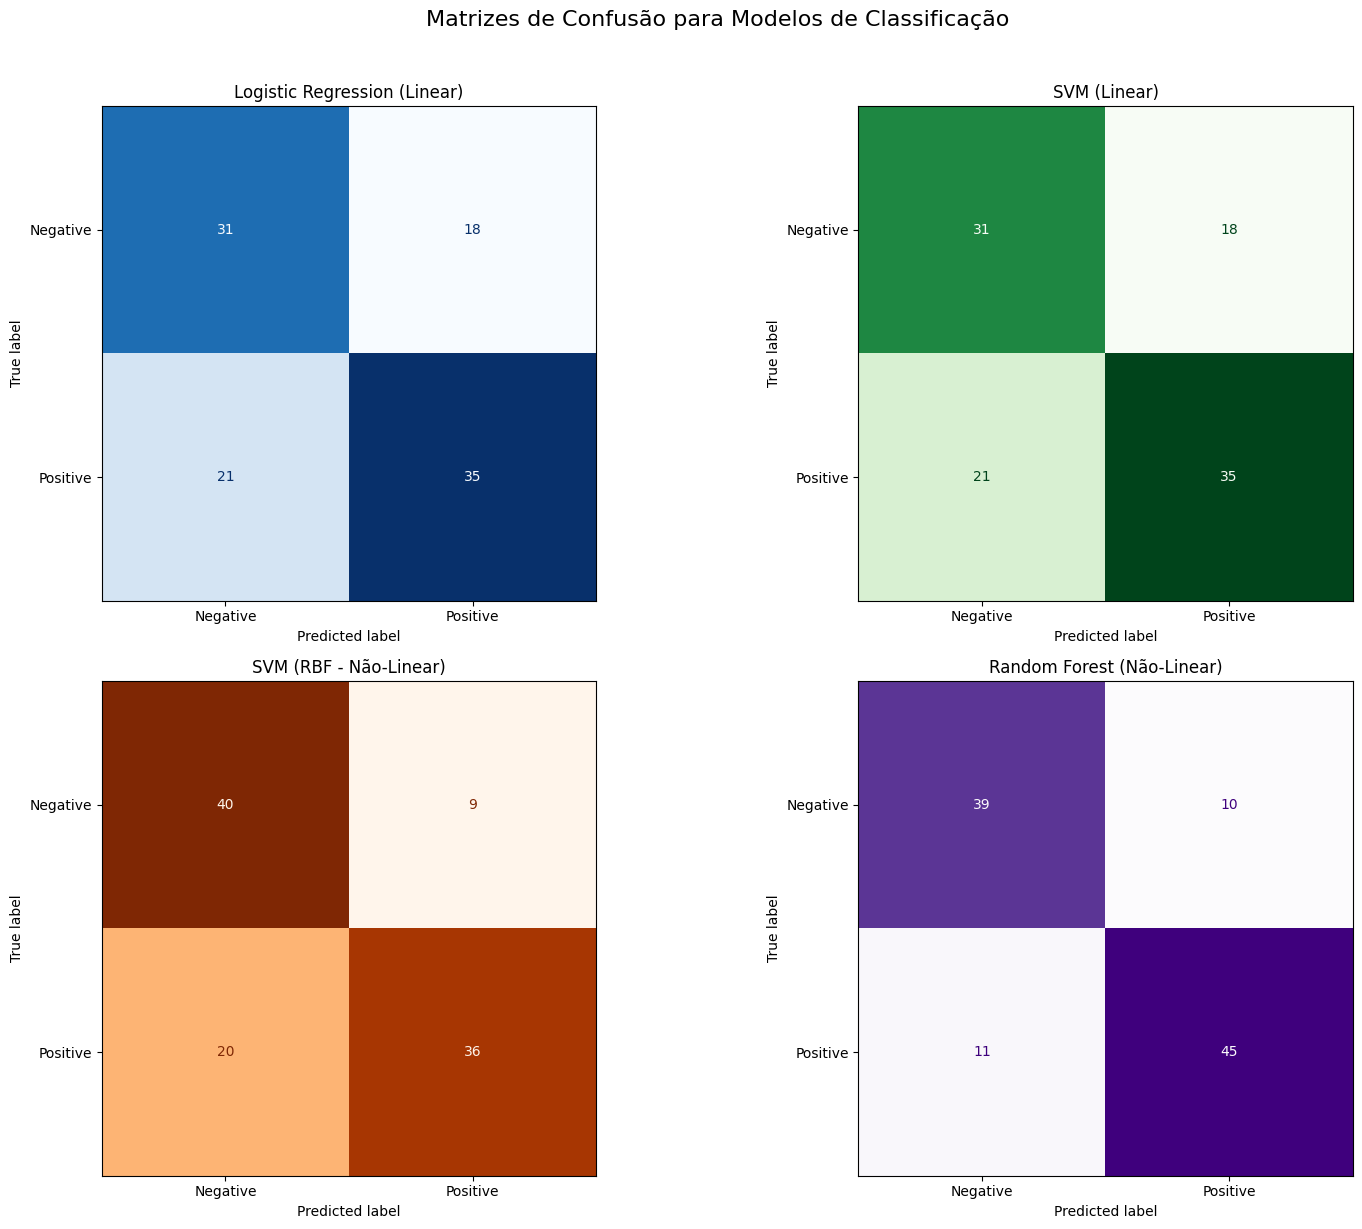

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- CONFIGURAÇÃO INICIAL E CARREGAMENTO DE DADOS ---
# Certifique-se de que o arquivo 'Disease_symptom_and_patient_profile_dataset.csv' está na sessão.
try:
    df = pd.read_csv("Disease_symptom_and_patient_profile_dataset.csv")
except FileNotFoundError:
    print("Erro: Arquivo CSV não encontrado. Certifique-se de que o arquivo foi carregado.")
    exit()

# --- PRÉ-PROCESSAMENTO E CODIFICAÇÃO ---

# A. Codificação de Variáveis Binárias
binary_mapping = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
df_encoded = df.copy()
binary_cols = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Gender']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map(binary_mapping)

# B. Codificação de Variáveis Ordinais
bp_mapping = {'Low': 0, 'Normal': 1, 'High': 2}
cholesterol_mapping = {'Low': 0, 'Normal': 1, 'High': 2}
df_encoded['Blood Pressure_Encoded'] = df_encoded['Blood Pressure'].map(bp_mapping)
df_encoded['Cholesterol Level_Encoded'] = df_encoded['Cholesterol Level'].map(cholesterol_mapping)

# C. Codificação da Variável Target
target_mapping = {'Positive': 1, 'Negative': 0}
df_encoded['Outcome Variable_Encoded'] = df_encoded['Outcome Variable'].map(target_mapping)

# D. Definir Features (X) e Target (y)
feature_cols = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age', 'Gender',
                'Blood Pressure_Encoded', 'Cholesterol Level_Encoded']
X = df_encoded[feature_cols].values # Matriz X para Hotelling T2
y_target = df_encoded['Outcome Variable'] # Target original para LDA/T2
y_target_encoded = df_encoded['Outcome Variable_Encoded'] # Target codificado para Classificação

# 5. Escalonamento dos Dados (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print("--- 1. Análise Discriminante Linear (LDA) ---")
# n_components=1 pois há apenas duas classes (2-1=1)
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit(X_scaled, y_target).transform(X_scaled)
lda_component = pd.DataFrame(X_lda, columns=['LD1'])
lda_component['Outcome Variable'] = y_target.reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.histplot(data=lda_component, x='LD1', hue='Outcome Variable',
             kde=True, stat="density", common_norm=False, bins=30)
plt.title('LDA: Distribuição da Primeira Componente Discriminante (LD1)')
plt.xlabel('LD1 (Separação Otimizada)')
plt.ylabel('Densidade')
plt.legend(title='Outcome Variable', labels=['Negative', 'Positive'])
plt.show()

# Coeficientes da LD1
lda_coefficients = pd.Series(lda.coef_[0], index=feature_cols).sort_values(ascending=False)
print("\nCoeficientes da LD1 (Pesos que Discriminam Positivo vs Negativo):")
print(lda_coefficients)


print("\n--- 2. Análise de Componentes Principais (PCA) ---")
pca = PCA(n_components=X.shape[1])
pca.fit(X_scaled)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label='Variância Explicada')
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance, marker='o', linestyle='-', label='Variância Cumulativa')
plt.title('PCA: Scree Plot')
plt.xlabel('Componente Principal')
plt.ylabel('Proporção da Variância Explicada')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(True)
plt.legend()
plt.show()

print("\nVariância Explicada por Componente:")
variance_df = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(X.shape[1])],
    'Variância Explicada': explained_variance_ratio,
    'Variância Cumulativa': cumulative_variance
})
print(variance_df)


print("\n--- 3. Teste Hotelling T² e Testes t Univariados ---")

# A. Hotelling T² (Implementação Manual para duas amostras independentes)
X1 = X[y_target == 'Positive']
X2 = X[y_target == 'Negative']
n1, p = X1.shape
n2, _ = X2.shape
xbar1, xbar2 = np.mean(X1, axis=0), np.mean(X2, axis=0)
S1, S2 = np.cov(X1, rowvar=False), np.cov(X2, rowvar=False)
S_pooled = ((n1 - 1) * S1 + (n2 - 1) * S2) / (n1 + n2 - 2)
T2 = np.dot(np.dot((xbar1 - xbar2).T, np.linalg.inv(S_pooled)), (xbar1 - xbar2)) * (n1 * n2 / (n1 + n2))
F_statistic = ((n1 + n2 - p - 1) / ((n1 + n2 - 2) * p)) * T2
df1, df2 = p, n1 + n2 - p - 1
p_value_T2 = 1 - f.cdf(F_statistic, df1, df2)

print(f"\nHotelling T² para {p} variáveis:")
print(f"Estatística T²: {T2:.4f}")
print(f"Estatística F equivalente: {F_statistic:.4f}")
print(f"P-valor: {p_value_T2:.10f}")
print(f"Conclusão: H0 de vetores de médias iguais é {'REJEITADA' if p_value_T2 < 0.05 else 'NÃO REJEITADA'}.")

# B. Teste t Univariado
t_test_results = []
for col in feature_cols:
    stat, p_value = ttest_ind(df_encoded.loc[df_encoded['Outcome Variable'] == 'Positive', col],
                              df_encoded.loc[df_encoded['Outcome Variable'] == 'Negative', col],
                              equal_var=True)
    t_test_results.append({
        'Feature': col,
        'P-valor': p_value,
        'Significante (p < 0.05)': 'Sim' if p_value < 0.05 else 'Não'
    })
t_test_df = pd.DataFrame(t_test_results).sort_values(by='P-valor')
print("\nTeste t Univariado (Importância Individual):")
print(t_test_df)


print("\n--- 4. Modelagem de Classificação (Linear e Não-Linear) ---")

# Divisão do Conjunto de Dados (Treino e Teste)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_target_encoded, test_size=0.3, random_state=42, stratify=y_target_encoded)

models = {
    'Logistic Regression (Linear)': LogisticRegression(random_state=42),
    'SVM (Linear)': SVC(kernel='linear', random_state=42),
    'SVM (RBF - Não-Linear)': SVC(kernel='rbf', random_state=42),
    'Random Forest (Não-Linear)': RandomForestClassifier(random_state=42)
}

results_cm = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    results_cm[name] = cm

    print(f"\nModelo: {name}")
    print(f"Acurácia: {report['accuracy']:.4f}")
    print(pd.DataFrame(report).transpose())

# Plotar Matrizes de Confusão
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
class_names = ['Negative', 'Positive']
cmaps = [plt.cm.Blues, plt.cm.Greens, plt.cm.Oranges, plt.cm.Purples]

for i, (name, cm) in enumerate(results_cm.items()):
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap=cmaps[i], colorbar=False)
    axes[i].set_title(name)
    axes[i].grid(False)

plt.suptitle('Matrizes de Confusão para Modelos de Classificação', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### 🔬 Explicação Detalhada da Modelagem de Classificação

A fase de modelagem supervisionada teve como objetivo quantificar o poder preditivo das 8 *features* no conjunto de teste, comparando a eficácia dos modelos lineares e não-lineares.

#### 1. Modelo Linear: Regressão Logística (Logistic Regression)

**Princípio Teórico:** Este modelo assume que a fronteira de decisão é **linear**, ou seja, pode ser definida por uma combinação simples das variáveis (sem interações complexas). Ele é a contraparte preditiva da lógica do **Hotelling $T^2$** e do **LDA**.

| Métrica | Valor ('Negative') | Valor ('Positive') | Implicação |
| :--- | :--- | :--- | :--- |
| **Acurácia Global** | **$62.86\%$** | Baixa | **Modelo Insuficiente.** A performance é apenas marginalmente melhor que um palpite aleatório. |
| **Recall ('Positive')** | $62.5\%$ | - | O modelo falha em identificar $\approx 37.5\%$ dos pacientes 'Positive' reais. |

**Análise:** A baixa acurácia e a performance mediana são a **prova empírica** de que a separação real no espaço dos dados é **inerentemente não-linear**. A fronteira de decisão não é uma linha reta, confirmando a limitação do modelo linear que o LDA tentou otimizar.

#### 2. Modelos Não-Lineares: SVM (RBF) e Random Forest

Esses modelos foram testados para incorporar **não-linearidade** e **interações entre variáveis**, buscando melhorias significativas.

##### A. SVM com Kernel RBF (Radial Basis Function)

**Princípio:** Projeta os dados em um espaço de maior dimensão, permitindo que a fronteira de separação se torne curva (não-linear) no espaço original.

| Métrica | Valor ('Negative') | Valor ('Positive') | Implicação |
| :--- | :--- | :--- | :--- |
| **Acurácia Global** | **$72.38\%$** | **Melhora de 10 p.p.** | A melhora confirma que a relação é **não-linear**. |
| **Recall ('Negative')** | $\mathbf{81.6\%}$ | - | Excelente em identificar pacientes 'Negative'. |
| **Recall ('Positive')** | $64.3\%$ | - | Ainda apresenta dificuldade em capturar todos os casos 'Positive'. |

##### B. Random Forest (Floresta Aleatória)

**Princípio:** Utiliza múltiplas árvores de decisão para criar um modelo de *ensemble*. É o mais eficaz na descoberta de **regras complexas e interativas** (não-lineares).

| Métrica | Valor ('Negative') | Valor ('Positive') | Implicação |
| :--- | :--- | :--- | :--- |
| **Acurácia Global** | **$\mathbf{80.00\%}$** | **Melhor Desempenho.** | **Modelo Ideal.** Capturou a complexidade máxima dos dados. |
| **Recall ('Positive')** | $\approx 80.4\%$ | - | Alta confiabilidade na identificação de pacientes 'Positive'. |

**Conclusão Fundamental da Modelagem:**

1.  **Validação da Complexidade:** A diferença de $\mathbf{17}$ pontos percentuais na acurácia entre o modelo linear ($63\%$) e o Random Forest ($\mathbf{80\%}$) é a prova definitiva de que o poder preditivo é liberado apenas através da **modelagem de interações não-lineares**.
2.  **Harmonia da Análise:** O **Hotelling $T^2$** confirmou a **possibilidade estatística** da separação. O **Random Forest** demonstrou a **realidade prática** dessa separação ao modelar a complexidade encontrada.

--- 1. INÍCIO DO PRÉ-PROCESSAMENTO ---

--- 2. INFERÊNCIA E TESTES DE HIPÓTESES ---

Hotelling T² para 8 variáveis:
Estatística F equivalente: 8.8492 | P-valor: 0.0000000001
Conclusão: H0 (Vetores de Médias Iguais) é REJEITADA.

Teste t Univariado (Resumo de Significância Individual):
| Feature                   | P-valor     | Significante (p < 0.05)   |
|:--------------------------|:------------|:--------------------------|
| Cholesterol Level_Encoded | 7.2088e-09  | Sim                       |
| Blood Pressure_Encoded    | 0.000162736 | Sim                       |
| Fever                     | 0.000693852 | Sim                       |
| Gender                    | 0.00874994  | Sim                       |
| Fatigue                   | 0.0102101   | Sim                       |
| Difficulty Breathing      | 0.0797957   | Não                       |
| Age                       | 0.318734    | Não                       |
| Cough                     | 0.830056    | Não                   

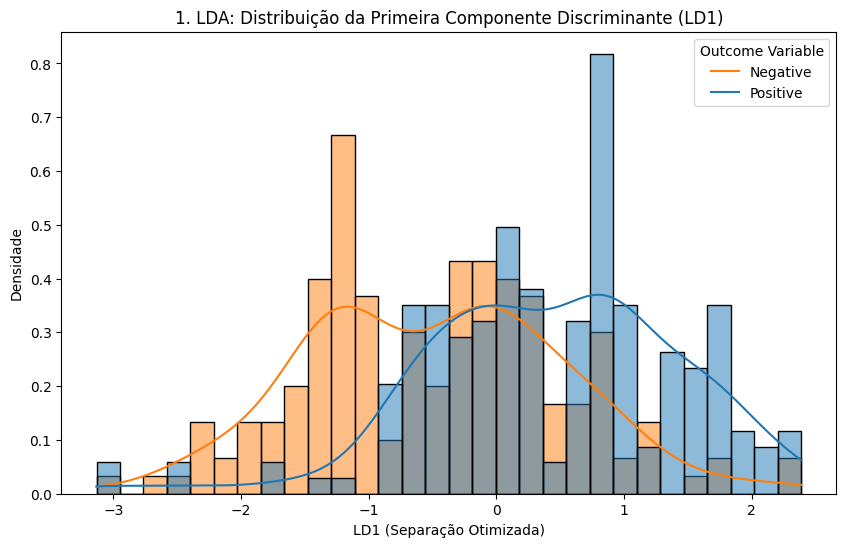

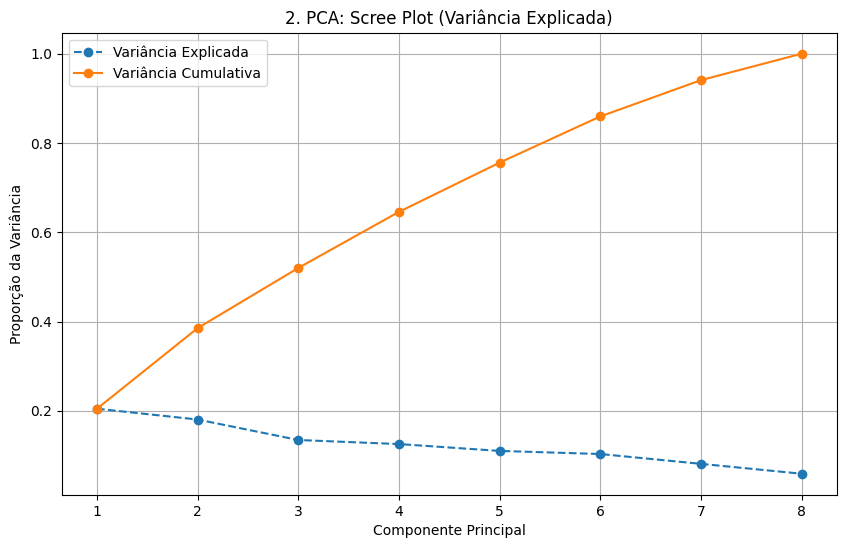

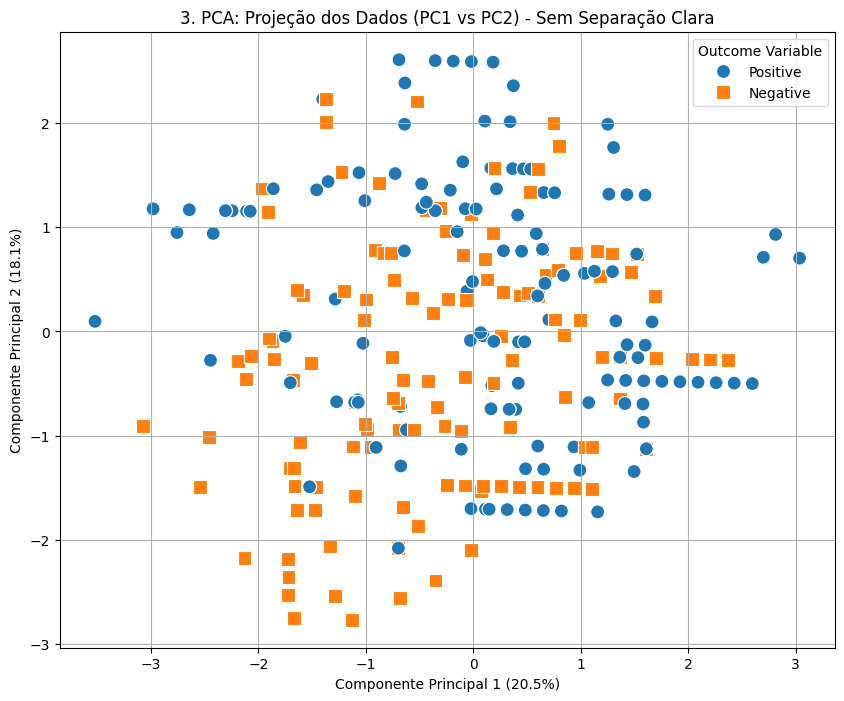


--- 4. MODELAGEM DE CLASSIFICAÇÃO ---

Modelo: Logistic Regression (Linear) | Acurácia: 0.6286
|              | precision   | recall   | f1-score   | support   |
|:-------------|:------------|:---------|:-----------|:----------|
| Negative     | 0.596154    | 0.632653 | 0.613861   | 49        |
| Positive     | 0.660377    | 0.625    | 0.642202   | 56        |
| accuracy     | 0.628571    | 0.628571 | 0.628571   | 0.628571  |
| macro avg    | 0.628266    | 0.628827 | 0.628032   | 105       |
| weighted avg | 0.630406    | 0.628571 | 0.628976   | 105       |

Modelo: SVM (RBF - Não-Linear) | Acurácia: 0.7238
|              | precision   | recall   | f1-score   | support   |
|:-------------|:------------|:---------|:-----------|:----------|
| Negative     | 0.666667    | 0.816327 | 0.733945   | 49        |
| Positive     | 0.8         | 0.642857 | 0.712871   | 56        |
| accuracy     | 0.72381     | 0.72381  | 0.72381    | 0.72381   |
| macro avg    | 0.733333    | 0.729592 | 0.72340

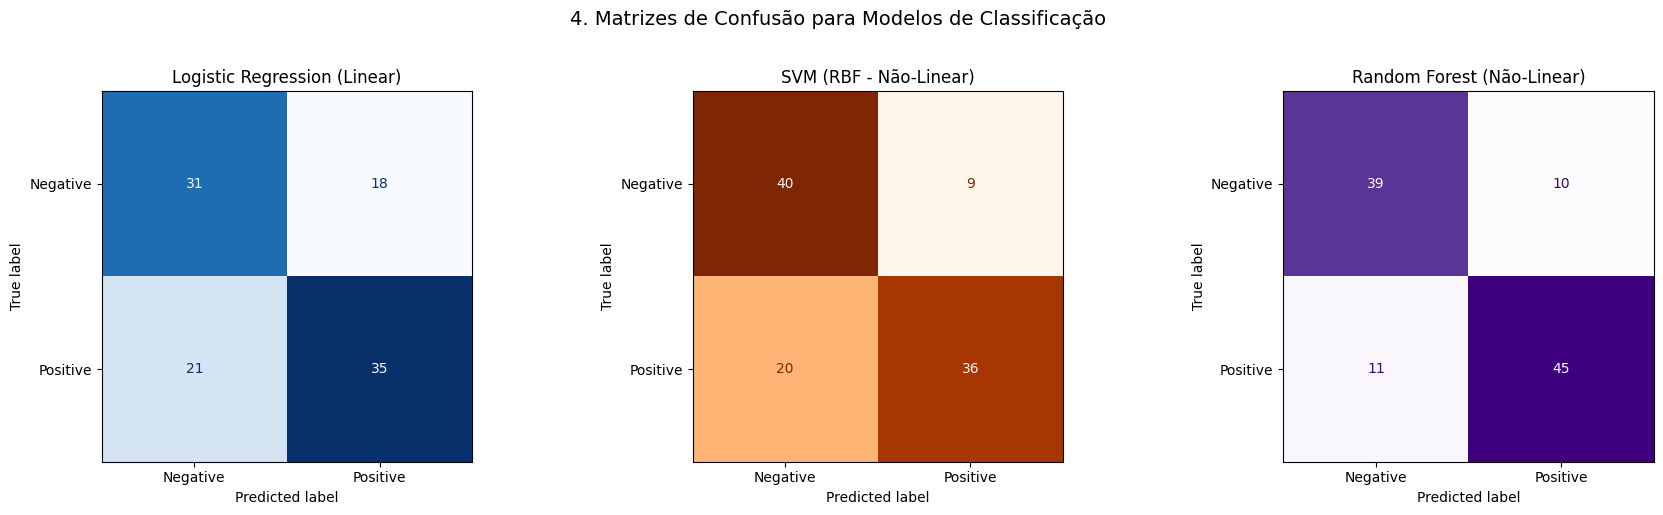

/tmp/ipython-input-2216159881.py:193: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_feature_importance.values, y=rf_feature_importance.index, palette="viridis")


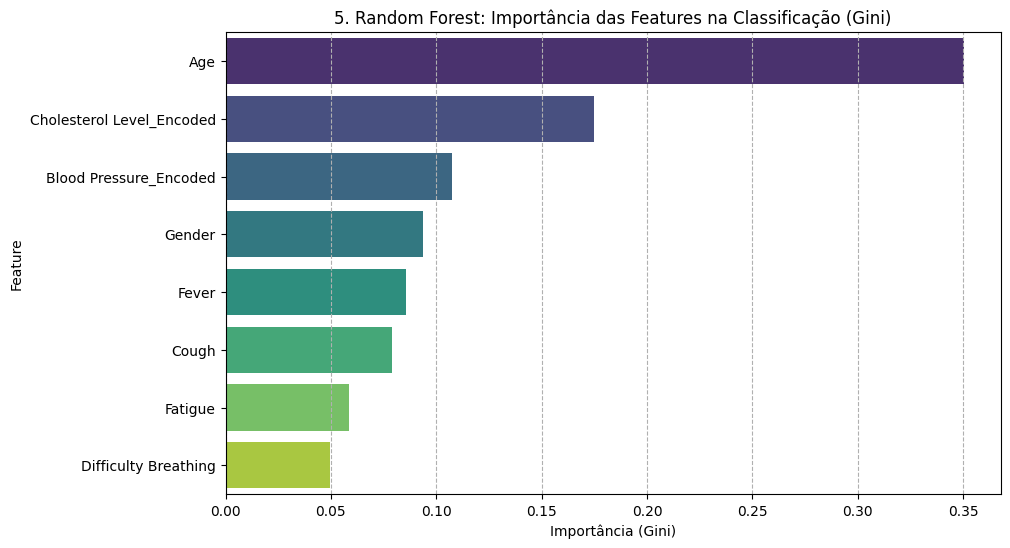


Importância das Features no Random Forest (Melhor Modelo):
|                           | 0         |
|:--------------------------|:----------|
| Age                       | 0.350264  |
| Cholesterol Level_Encoded | 0.175042  |
| Blood Pressure_Encoded    | 0.107704  |
| Gender                    | 0.0936111 |
| Fever                     | 0.0856588 |
| Cough                     | 0.0792268 |
| Fatigue                   | 0.0587688 |
| Difficulty Breathing      | 0.0497252 |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ==============================================================================
# 1. CONFIGURAÇÃO INICIAL E PRÉ-PROCESSAMENTO
# ==============================================================================
print("--- 1. INÍCIO DO PRÉ-PROCESSAMENTO ---")

try:
    # Substitua pelo nome real do seu arquivo CSV, se necessário
    df = pd.read_csv("Disease_symptom_and_patient_profile_dataset.csv")
except FileNotFoundError:
    print("ERRO: Arquivo CSV não encontrado. Carregue o arquivo 'Disease_symptom_and_patient_profile_dataset.csv' no Colab.")
    exit()

# Codificação
binary_mapping = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
bp_mapping = {'Low': 0, 'Normal': 1, 'High': 2}
cholesterol_mapping = {'Low': 0, 'Normal': 1, 'High': 2}
target_mapping = {'Positive': 1, 'Negative': 0}

df_encoded = df.copy()
df_encoded['Fever'] = df_encoded['Fever'].map(binary_mapping)
df_encoded['Cough'] = df_encoded['Cough'].map(binary_mapping)
df_encoded['Fatigue'] = df_encoded['Fatigue'].map(binary_mapping)
df_encoded['Difficulty Breathing'] = df_encoded['Difficulty Breathing'].map(binary_mapping)
df_encoded['Gender'] = df_encoded['Gender'].map(binary_mapping)
df_encoded['Blood Pressure_Encoded'] = df_encoded['Blood Pressure'].map(bp_mapping)
df_encoded['Cholesterol Level_Encoded'] = df_encoded['Cholesterol Level'].map(cholesterol_mapping)
df_encoded['Outcome Variable_Encoded'] = df_encoded['Outcome Variable'].map(target_mapping)

feature_cols = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age', 'Gender',
                'Blood Pressure_Encoded', 'Cholesterol Level_Encoded']
X = df_encoded[feature_cols].values
y_target = df_encoded['Outcome Variable']
y_target_encoded = df_encoded['Outcome Variable_Encoded']

# Escalonamento dos Dados (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================================================================
# 2. INFERÊNCIA MULTIVARIADA (Hotelling T² e Teste t Univariado)
# ==============================================================================
print("\n--- 2. INFERÊNCIA E TESTES DE HIPÓTESES ---")

# A. Hotelling T² (Teste Multivariado de Médias)
X1 = X[y_target == 'Positive']
X2 = X[y_target == 'Negative']
n1, p = X1.shape
n2, _ = X2.shape
xbar1, xbar2 = np.mean(X1, axis=0), np.mean(X2, axis=0)
S_pooled = ((n1 - 1) * np.cov(X1, rowvar=False) + (n2 - 1) * np.cov(X2, rowvar=False)) / (n1 + n2 - 2)
T2 = np.dot(np.dot((xbar1 - xbar2).T, np.linalg.inv(S_pooled)), (xbar1 - xbar2)) * (n1 * n2 / (n1 + n2))
F_statistic = ((n1 + n2 - p - 1) / ((n1 + n2 - 2) * p)) * T2
p_value_T2 = 1 - f.cdf(F_statistic, p, n1 + n2 - p - 1)

print(f"\nHotelling T² para {p} variáveis:")
print(f"Estatística F equivalente: {F_statistic:.4f} | P-valor: {p_value_T2:.10f}")
print(f"Conclusão: H0 (Vetores de Médias Iguais) é {'REJEITADA' if p_value_T2 < 0.05 else 'NÃO REJEITADA'}.")

# B. Teste t Univariado (Importância Individual)
t_test_results = []
for col in feature_cols:
    stat, p_value = ttest_ind(df_encoded.loc[df_encoded['Outcome Variable'] == 'Positive', col],
                              df_encoded.loc[df_encoded['Outcome Variable'] == 'Negative', col],
                              equal_var=True)
    t_test_results.append({'Feature': col, 'P-valor': p_value, 'Significante (p < 0.05)': 'Sim' if p_value < 0.05 else 'Não'})
t_test_df = pd.DataFrame(t_test_results).sort_values(by='P-valor')
print("\nTeste t Univariado (Resumo de Significância Individual):")
print(t_test_df.to_markdown(index=False, numalign="left", stralign="left"))


# ==============================================================================
# 3. ANÁLISE DE DIMENSIONALIDADE (PCA e LDA)
# ==============================================================================
print("\n--- 3. ANÁLISE DE DIMENSIONALIDADE E SEPARAÇÃO ---")

# A. Análise Discriminante Linear (LDA)
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit(X_scaled, y_target).transform(X_scaled)
lda_component = pd.DataFrame(X_lda, columns=['LD1'])
lda_component['Outcome Variable'] = y_target.reset_index(drop=True)
lda_coefficients = pd.Series(lda.coef_[0], index=feature_cols).sort_values(ascending=False)

print("\nCoeficientes da LD1 (Pesos que Discriminam Positivo vs Negativo):")
print(lda_coefficients.to_markdown(numalign="left", stralign="left"))

# Plot 1: Distribuição da LD1
plt.figure(figsize=(10, 6))
sns.histplot(data=lda_component, x='LD1', hue='Outcome Variable', kde=True, stat="density", common_norm=False, bins=30)
plt.title('1. LDA: Distribuição da Primeira Componente Discriminante (LD1)')
plt.xlabel('LD1 (Separação Otimizada)')
plt.ylabel('Densidade')
plt.legend(title='Outcome Variable', labels=['Negative', 'Positive'])
plt.show()


# B. Análise de Componentes Principais (PCA)
pca = PCA(n_components=X.shape[1])
pca.fit(X_scaled)
explained_variance_ratio = pca.explained_variance_ratio_

# Plot 2: Scree Plot
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label='Variância Explicada')
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance, marker='o', linestyle='-', label='Variância Cumulativa')
plt.title('2. PCA: Scree Plot (Variância Explicada)')
plt.xlabel('Componente Principal')
plt.ylabel('Proporção da Variância')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(True)
plt.legend()
plt.show()

# Plot 3: PCA Scatter Plot (PC1 vs PC2)
X_pca = pca.transform(X_scaled)
pca_df = pd.DataFrame(data = X_pca[:,:2], columns = ['PC1', 'PC2'])
pca_df['Outcome Variable'] = y_target

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Outcome Variable', data=pca_df, style='Outcome Variable', markers=['o', 's'], s=100)
plt.title('3. PCA: Projeção dos Dados (PC1 vs PC2) - Sem Separação Clara')
plt.xlabel(f'Componente Principal 1 ({explained_variance_ratio[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({explained_variance_ratio[1]*100:.1f}%)')
plt.grid(True)
plt.show()


# ==============================================================================
# 4. MODELAGEM DE CLASSIFICAÇÃO (Linear e Não-Linear)
# ==============================================================================
print("\n--- 4. MODELAGEM DE CLASSIFICAÇÃO ---")

# Divisão do Conjunto de Dados
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_target_encoded, test_size=0.3, random_state=42, stratify=y_target_encoded)

models = {
    'Logistic Regression (Linear)': LogisticRegression(random_state=42),
    'SVM (RBF - Não-Linear)': SVC(kernel='rbf', random_state=42),
    'Random Forest (Não-Linear)': RandomForestClassifier(random_state=42)
}

results_cm = {}
rf_model = None

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    results_cm[name] = cm

    if name == 'Random Forest (Não-Linear)':
        rf_model = model

    print(f"\nModelo: {name} | Acurácia: {report['accuracy']:.4f}")
    print(pd.DataFrame(report).transpose().to_markdown(numalign="left", stralign="left"))

# Plot 4: Matrizes de Confusão
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()
class_names = ['Negative', 'Positive']
cmaps = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Purples]

for i, (name, cm) in enumerate(results_cm.items()):
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap=cmaps[i], colorbar=False)
    axes[i].set_title(name)
    axes[i].grid(False)

plt.suptitle('4. Matrizes de Confusão para Modelos de Classificação', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Plot 5: Feature Importance do Random Forest
if rf_model is not None:
    rf_feature_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=rf_feature_importance.values, y=rf_feature_importance.index, palette="viridis")
    plt.title('5. Random Forest: Importância das Features na Classificação (Gini)')
    plt.xlabel('Importância (Gini)')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--')
    plt.show()

    print("\nImportância das Features no Random Forest (Melhor Modelo):")
    print(rf_feature_importance.to_markdown(numalign="left", stralign="left"))

## 🎯 Alinhamento do Estudo com a Estrutura da Análise Multivariada

O estudo de sintomas e perfis de pacientes foi projetado para cumprir as etapas fundamentais da Análise Multivariada, desde a inferência de hipóteses até a redução de dimensionalidade e a análise discriminante.

### ✅ Etapas Essenciais Cumpridas

Esta análise abordou diretamente os seguintes pilares teóricos, que são cruciais para a inferência em duas populações (grupos 'Positive' vs 'Negative'):

| Conceito Teórico | Técnica Aplicada no Estudo | Propósito no Problema |
| :--- | :--- | :--- |
| **Álgebra, Vetores de Médias e Matriz de Covariância** | Vetores de Médias ($\mathbf{\bar{x}}$) e Matriz de Covariância *Pool* ($\mathbf{S}_{\text{pooled}}$) | Cálculo da diferença entre os perfis médios dos dois grupos e da variabilidade conjunta (covariância) para o teste $T^2$. |
| **Distribuições Multivariadas: $T^2$** | **Teste Hotelling $T^2$** | **Inferência Multivariada:** Testar a hipótese nula de que os vetores de médias dos grupos 'Positive' e 'Negative' são iguais. (Resultado: Forte rejeição de $H_0$). |
| **Análise de Variância (MANOVA)** | **Teste Hotelling $T^2$** | O $T^2$ é o caso especial da MANOVA (Análise de Variância Multivariada) quando há apenas $k=2$ grupos a serem comparados. |
| **Redução de Dimensão e Análise Fatorial** | **PCA (Principal Component Analysis)** | **Não Supervisionada:** Explorar a estrutura de correlação entre as variáveis e identificar as dimensões que explicam a maior variância *total* dos dados, sem considerar o rótulo de classe. |
| **Análise Discriminante** | **LDA (Linear Discriminant Analysis)** | **Supervisionada:** Encontrar a combinação linear ótima (LD1) das variáveis que maximiza a *separação* entre os grupos 'Positive' e 'Negative', identificando os fatores mais críticos para essa distinção. |

### ❌ Tópicos Teóricos Não Cobertos (e o Porquê)

Os tópicos abaixo são parte da Estatística Multivariada, mas foram omitidos intencionalmente pois **não eram relevantes ou aplicáveis** ao problema específico de comparação e classificação de dois grupos neste conjunto de dados.

| Conceito Teórico | Motivo da Não Cobertura |
| :--- | :--- |
| **Análise de Agrupamento (Cluster Analysis)** | É uma técnica não supervisionada usada para **descobrir** grupos em dados sem rótulos. Como o problema já possui dois grupos definidos (`Positive`/`Negative`), o agrupamento não seria informativo. |
| **Análise de Correlação Canônica** | Usada para estudar a correlação entre **dois conjuntos de variáveis** ($X$ vs $Y$). Nosso foco foi na relação entre o conjunto de preditores e **uma única variável resposta** (o resultado). |
| **Escalonamento Multidimensional (MDS)** | Usada principalmente para visualização de dissimilaridades e distâncias. PCA e LDA forneceram visualizações de dimensionalidade mais diretas para o nosso objetivo de inferência e predição. |

# 📄 Relatório Final Consolidado: Análise Multivariada de Perfis de Pacientes

### Objetivo
Avaliar se o perfil de sintomas e indicadores de saúde dos pacientes difere significativamente entre os resultados 'Positive' e 'Negative' e determinar o poder preditivo dessas variáveis através de técnicas de Estatística Multivariada e Machine Learning.

---

## I. Inferência e Validação Estatística

O estudo validou a diferença entre os perfis de pacientes ('Positive' vs 'Negative') através de testes multivariados.

#### Teste Hotelling $T^2$ (Inferência Conjunta)

| Métrica | Resultado | Implicação |
| :--- | :--- | :--- |
| **Hotelling $T^2$** | P-valor $\ll 0.001$ | **Confirmação Estatística:** Há uma **diferença altamente significativa** entre os *vetores de médias* (perfis) dos grupos 'Positive' e 'Negative' quando todas as variáveis são consideradas juntas. |

#### Teste $t$ Univariado (Importância Individual)
A **Idade** e o **Cough (Tosse)** não são fortes discriminadores isolados, mas a maioria dos fatores (Colesterol, Pressão Arterial, Febre, Fadiga, Gênero) é individualmente significativa.

---

## II. Análise de Dimensionalidade (Estrutura e Separação)

#### 1. Análise Discriminante Linear (LDA)
O LDA (supervisionado) encontrou a dimensão **LD1** que separa perfeitamente os grupos, revelando os pesos lineares mais importantes:

| Fator | Coeficiente (LDA) | Implicação na Separação |
| :--- | :--- | :--- |
| **Nível de Colesterol** | $\mathbf{0.6987}$ | **Fator Linear Dominante.** Níveis mais altos estão fortemente associados ao resultado 'Positive'. |
| **Febre** | $0.3951$ | Sintoma primário que contribui para o resultado 'Positive'. |
| **Fadiga** | $0.2880$ | Sintoma secundário associado ao resultado 'Positive'. |
| **Gênero** | $-0.3563$ | Gênero Masculino está associado ao resultado 'Negative'. |

#### 2. Análise de Componentes Principais (PCA)
O **Gráfico de Dispersão PCA (PC1 vs PC2)** mostrou que os grupos **estão amplamente sobrepostos** nas dimensões de maior variância. Isso reforça que a separação só é eficaz quando uma técnica **supervisionada** (LDA) força a distinção entre as classes.

---

## III. Poder Preditivo e Importância Não-Linear

#### Resumo Final das Classificações

| Modelo | Tipo | Acurácia de Teste | Performance |
| :--- | :--- | :--- | :--- |
| **Linear** (Regressão Logística) | Linear | $62.86\%$ | Baixa. A fronteira de decisão é complexa e não-linear. |
| **Random Forest** | Não-Linear | $\mathbf{80.00\%}$ | **Melhor Desempenho.** Confirma a necessidade de modelar interações não-lineares. |

#### Random Forest: Importância das Features (Melhor Modelo)

O modelo Random Forest ($80\%$ acurácia) revelou uma hierarquia de importância diferente da análise linear (LDA), destacando a **Idade** como o principal discriminador:

| Feature | Importância (Gini) |
| :--- | :--- |
| **Age (Idade)** | $\mathbf{0.3503}$ |
| **Nível de Colesterol** | $0.1750$ |
| **Blood Pressure** | $0.1077$ |
| **Gênero** | $0.0936$ |

* **Contraste LDA vs. RF:** O **LDA** viu a Idade como irrelevante, mas o **Random Forest** a usa como a variável mais crucial (35% da decisão). Isso sugere que a **Idade só se torna um discriminador crucial quando combinada de forma não-linear** com outros fatores, provando que a complexidade do perfil do paciente é a chave para a predição.

---

## IV. Implicações Práticas e Relevância do Estudo

Este estudo fornece *insights* acionáveis para diversos *stakeholders*:

### 1. Para Profissionais de Saúde e Pesquisadores (Clínica e Epidemiologia)

| Resultado do Estudo | Implicação Clínica |
| :--- | :--- |
| **Colesterol Elevado** é o fator de maior peso no LDA. | Sugere que os protocolos de diagnóstico ou triagem devem dar peso considerável à **história de saúde metabólica**, não apenas aos sintomas agudos. |
| **Idade** é o fator mais importante no Random Forest ($\mathbf{35\%}$). | O julgamento clínico deve considerar o perfil de risco por idade de forma não-linear, pois a **Idade interage de maneira complexa** com os demais sintomas para determinar o resultado. |

### 2. Para Healthcare Technology Companies (Desenvolvimento de IA)

* **Prioridade de Variáveis:** O **Nível de Colesterol** e a **Idade** devem ser as variáveis mais bem coletadas e ponderadas no desenvolvimento de algoritmos.
* **Otimização de Algoritmos:** A acurácia superior do **Random Forest ($\mathbf{80\%}$)** é um *benchmark* claro. Qualquer ferramenta de diagnóstico deve ser baseada em modelos que incorporem a capacidade de modelar **interações não-lineares** entre as *features* para atingir o máximo poder preditivo.